<a href="https://colab.research.google.com/github/AditiAICodes/Autobahn-Data-Analysis/blob/main/Phase_4/02_SMOTE_Optimized_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import userdata

# 1. Pull the token from the vault using the exact name you saved it as!
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

print("✅ Active!")


✅ Active!


In [ ]:

!kaggle datasets download -d "parvmodi/automotive-vehicles-engine-health-dataset"

!unzip -o automotive-vehicles-engine-health-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/parvmodi/automotive-vehicles-engine-health-dataset
License(s): CC0-1.0
100% 595k/595k [00:00<00:00, 22.7MB/s]

Archive:  automotive-vehicles-engine-health-dataset.zip
  inflating: engine_data.csv         


In [ ]:
import pandas as pd

df_engine = pd.read_csv('engine_data.csv')

df_engine.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
0,700,2.493592,11.790927,3.178981,84.144163,81.632187,1
1,876,2.941606,16.193866,2.464504,77.640934,82.445724,0
2,520,2.961746,6.553147,1.064347,77.752266,79.645777,1
3,473,3.707835,19.510172,3.727455,74.129907,71.774629,1
4,619,5.672919,15.738871,2.052251,78.396989,87.000225,0


In [ ]:
#A)EDA (Exploratory Data Analysis)

#EDA Phase 1: Surface-level scan
# 1. Check the data types and see if any rows are missing (NaN)
print("--- ENGINE DATA INFO ---")
df_engine.info()
print("")

# 2. Get the statistical summary
print("\n--- STATISTICAL SUMMARY ---")
df_engine.describe()


--- ENGINE DATA INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Engine rpm        19535 non-null  int64  
 1   Lub oil pressure  19535 non-null  float64
 2   Fuel pressure     19535 non-null  float64
 3   Coolant pressure  19535 non-null  float64
 4   lub oil temp      19535 non-null  float64
 5   Coolant temp      19535 non-null  float64
 6   Engine Condition  19535 non-null  int64  
dtypes: float64(5), int64(2)
memory usage: 1.0 MB


--- STATISTICAL SUMMARY ---


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
count,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000
mean,791.239263,3.303775,6.655615,2.335369,77.643420,78.427433,0.630509
std,267.611193,1.021643,2.761021,1.036382,3.110984,6.206749,0.482679
min,61.000000,0.003384,0.003187,0.002483,71.321974,61.673325,0.000000
25%,593.000000,2.518815,4.916886,1.600466,75.725990,73.895421,0.000000
50%,746.000000,3.162035,6.201720,2.166883,76.817350,78.346662,1.000000
75%,934.000000,4.055272,7.744973,2.848840,78.071691,82.915411,1.000000
max,2239.000000,7.265566,21.138326,7.478505,89.580796,195.527912,1.000000


In [ ]:
# 3. See how many 'Failures' vs 'Normal' states we have
print("\n--- ENGINE CONDITION COUNTS ---")
print(df_engine['Engine Condition'].value_counts())


--- ENGINE CONDITION COUNTS ---
Engine Condition
1    12317
0     7218
Name: count, dtype: int64


In [ ]:
# FEATURE ENGINEERING
print(" Inventing custom mechanical sensors...")

# 1. The Temperature Gap (Oil Temp minus Coolant Temp)
df_engine['Temp_Gap'] = df_engine['lub oil temp'] - df_engine['Coolant temp']

# 2. The Pressure Gap (Oil Pressure minus Fuel Pressure)
df_engine['Pressure_Gap'] = df_engine['Lub oil pressure'] - df_engine['Fuel pressure']

print("✅ Custom Sensors Installed! Here is the new blueprint:")
df_engine[['lub oil temp', 'Coolant temp', 'Temp_Gap', 'Pressure_Gap']].head()

 Inventing custom mechanical sensors...
✅ Custom Sensors Installed! Here is the new blueprint:


,lub oil temp,Coolant temp,Temp_Gap,Pressure_Gap
0,2.089663,0.516347,1.573317,-2.653020
1,-0.000799,0.647423,-0.648222,-3.809205
2,0.034988,0.196298,-0.161310,-0.297679
3,-1.129418,-1.071894,-0.057525,-4.260335
4,0.242235,1.381240,-1.139006,-0.970889


 CORRELATION HEATMAP 


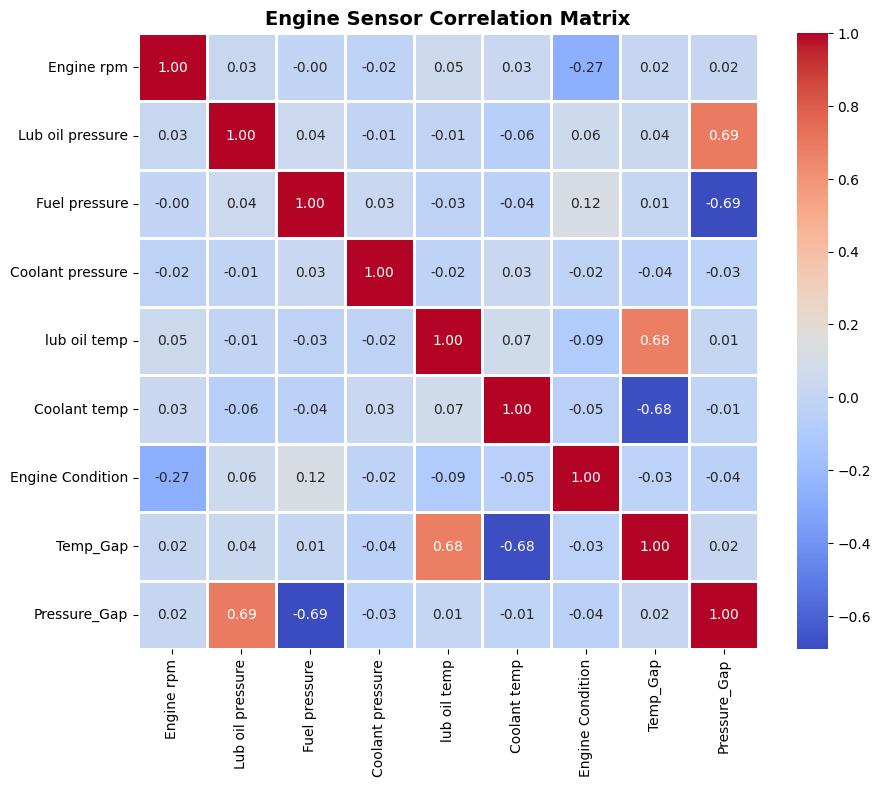

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print(" CORRELATION HEATMAP ")

# 1. Set up the canvas size
plt.figure(figsize=(10, 8))

# 2. Calculate the math and draw the Heatmap!
# (We use annot=True so it prints the exact decimal numbers inside the boxes)
sns.heatmap(df_engine.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=1)

# 3. Add a badass title
plt.title('Engine Sensor Correlation Matrix', fontsize=14, fontweight='bold')
plt.show()

In [ ]:
# Heatmap shows that new engineered features (Temp_Gap and Pressure_Gap) had almost zero correlation with the engine condition (0.02 and -0.01).
df_engine = df_engine.drop(columns=['Temp_Gap', 'Pressure_Gap'])

print(" DATASET CLEANED ")
print(f"Current columns: {df_engine.columns.tolist()}")

 DATASET CLEANED 
Current columns: ['Engine rpm', 'Lub oil pressure', 'Fuel pressure', 'Coolant pressure', 'lub oil temp', 'Coolant temp', 'Engine Condition']


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Pick the sensors
features_to_scale = ['Engine rpm', 'Lub oil pressure', 'Fuel pressure', 'Coolant pressure', 'lub oil temp', 'Coolant temp']

# 1. SPLIT FIRST
X = df_engine[features_to_scale]
y = df_engine['Engine Condition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. SCALE AFTER SPLIT (Zero Leakage of Test data)
scaler = StandardScaler()

# .fit_transform learns the rules from the Study Guide and squishes it
X_train_scaled = scaler.fit_transform(X_train)

# .transform ONLY squishes the Final Exam (No learning allowed)
X_test_scaled = scaler.transform(X_test)

print("✅ Complete! Your engine data is safely split, scaled, and ready for the AI.")





✅ Complete! Your engine data is safely split, scaled, and ready for the AI.


In [ ]:
from sklearn.model_selection import train_test_split


# X = The Sensors (Questions)
X = df_engine[['Engine rpm', 'Lub oil pressure', 'Fuel pressure', 'Coolant pressure', 'lub oil temp', 'Coolant temp']]
# y = The Target (Answer Key)
y = df_engine['Engine Condition']

# (test_size=0.2 means 20%. random_state=42 just ensures we shuffle the deck the exact same way every time)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Rows for the AI to study (X_train): {X_train.shape[0]}")
print(f"Rows locked for testing data (X_test): {X_test.shape[0]}")

Rows for the AI to study (X_train): 15628
Rows locked for testing data (X_test): 3907


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Build the blank ML Model
# random_state=42 just makes sure tool behave the exact same way every time you run the code
ai_brain = RandomForestClassifier(random_state=42)

print("The AI is studying the 15,628 engine blueprints... please wait...")

# The .fit() command forces them to look at the Questions (X_train) and the Answers (y_train) to find patterns.
ai_brain.fit(X_train, y_train)

print("✅ Studying complete! The AI is officially trained.")

The AI is studying the 15,628 engine blueprints... please wait...
✅ Studying complete! The AI is officially trained.


The AI is taking the test
 SCORE: 63.55% 

 (Confusion Matrix)


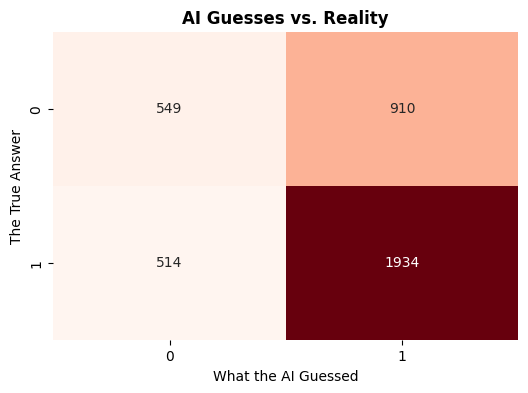

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 5. Force the AI to take the Final Exam on the hidden data!
print("The AI is taking the test")
predictions = ai_brain.predict(X_test)

# 6. Grade the Exam! (Compare guesses to the real answer key)
score = accuracy_score(y_test, predictions)
print(f" SCORE: {score * 100:.2f}% ")

# The second word (Positive/Negative) is just whatever the AI guessed.
#The first word (True/False) tells you if the AI was right or wrong.
print("\n (Confusion Matrix)")
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('AI Guesses vs. Reality', fontweight='bold')
plt.xlabel('What the AI Guessed')
plt.ylabel('The True Answer')
plt.show()


 NEW CONFUSION MATRIX


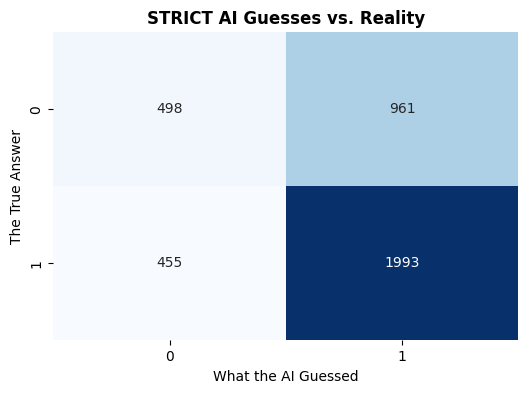

In [ ]:
# class_weight='balanced' forces the AI to pay massive attention to the rare "Broken (0)" engines.
strict_ai_brain = RandomForestClassifier(class_weight='balanced', random_state=42)

# 2. Force them to study the flashcards again

strict_ai_brain.fit(X_train, y_train)

# 3. Take the Final Exam blind
strict_predictions = strict_ai_brain.predict(X_test)

# 4. Run the Lie Detector again!
print("\n NEW CONFUSION MATRIX")
new_cm = confusion_matrix(y_test, strict_predictions)


plt.figure(figsize=(6, 4))
sns.heatmap(new_cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('STRICT AI Guesses vs. Reality', fontweight='bold')
plt.xlabel('What the AI Guessed')
plt.ylabel('The True Answer')
plt.show()

In [ ]:
# (You might need to run: !pip install imbalanced-learn  in a cell above this if you get an error!)
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

print(" INITIATING DATA ALCHEMY (SMOTE)...")

# 1. Initialize SMOTE
smote = SMOTE(random_state=42)

# 2. we NEVER, EVER run SMOTE on the Final Exam (X_test)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Old Study Guide: {len(y_train)} engines")
print(f"New SMOTE Study Guide: {len(y_train_smote)} engines! (Perfectly balanced )")

# 3. Build a standard AI brain (We don't need the 'balanced' strict anymore, the data is balanced!)
smote_ai_brain = RandomForestClassifier(random_state=42)

# 4. Train on the Hallucinated Data
print("The AI is studying the new, massive SMOTE textbook...")
smote_ai_brain.fit(X_train_smote, y_train_smote)

# 5. Test on the REAL, UNTOUCHED Final Exam
smote_predictions = smote_ai_brain.predict(X_test_scaled)

# 6. Accuracy
smote_score = accuracy_score(y_test, smote_predictions)
print(f"\n SMOTE SCORE: {smote_score * 100:.2f}% ---")



 INITIATING DATA ALCHEMY (SMOTE)...
Old Study Guide: 15628 engines
New SMOTE Study Guide: 19738 engines! (Perfectly balanced )
The AI is studying the new, massive SMOTE textbook...

 SMOTE SCORE: 62.89% ---


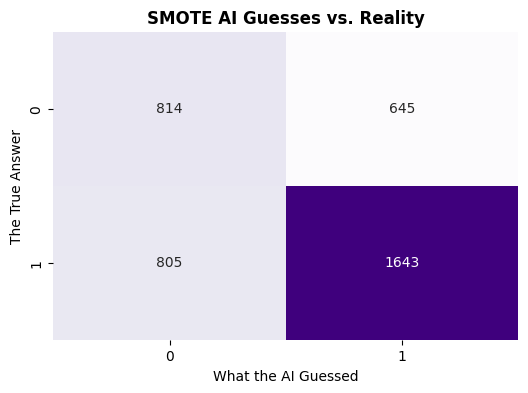

In [ ]:
# 7. The Final confusion matrix
#Top-Left (0,0): The Heroes (Caught the exploding engines).
#Top-Right (0,1): The Catastrophes (Missed the exploding engines—they drove away).
#Bottom-Left (1,0): The False Alarms (Held back healthy cars).
#Bottom-Right (1,1): The Easy Points (Cleared healthy cars).
cm = confusion_matrix(y_test, smote_predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title('SMOTE AI Guesses vs. Reality', fontweight='bold')
plt.xlabel('What the AI Guessed')
plt.ylabel('The True Answer')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print("📊 OFFICIAL AI REPORT CARD (SMOTE MODEL) 📊\n")
# This prints the Precision, Recall, and F1 for both Healthy(1) and Broken(0) engines
print(classification_report(y_test, smote_predictions))

📊 OFFICIAL AI REPORT CARD (SMOTE MODEL) 📊

              precision    recall  f1-score   support

           0       0.50      0.56      0.53      1459
           1       0.72      0.67      0.69      2448

    accuracy                           0.63      3907
   macro avg       0.61      0.61      0.61      3907
weighted avg       0.64      0.63      0.63      3907



In [ ]:
import joblib

# 1. Save the AI Brain
joblib.dump(smote_ai_brain, 'autobahn_ai_model.joblib')
print("✅ AI Brain saved as 'autobahn_ai_model.joblib'")

# 2. Save the Scaler (The Squisher)
joblib.dump(scaler, 'autobahn_scaler.joblib')
print("✅ Scaler saved as 'autobahn_scaler.joblib'")

print("\nPROJECT COMPLETE! You can now install these files in any garage in the world!")

✅ AI Brain saved as 'autobahn_ai_model.joblib'
✅ Scaler saved as 'autobahn_scaler.joblib'

PROJECT COMPLETE! You can now install these files in any garage in the world!
